# Regression

# Supernovae Distances and Redshifts

In [1]:
from astropy.cosmology import LambdaCDM
from astroML.datasets import generate_mu_z
import astroML.linear_model
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_predict

/opt/anaconda3/lib/python3.12/site-packages/astroML/linear_model/linear_regression_errors.py:10: UserWarning: LinearRegressionwithErrors requires PyMC3 to be installed
  warnings.warn('LinearRegressionwithErrors requires PyMC3 to be installed')


Synthetic SNIa data

(35.0, 50.0)

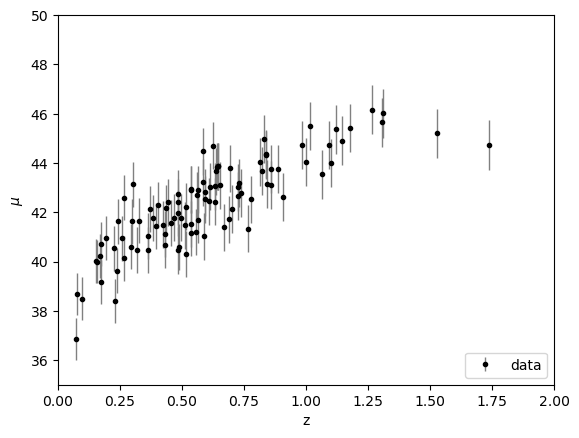

In [2]:
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel(rf"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

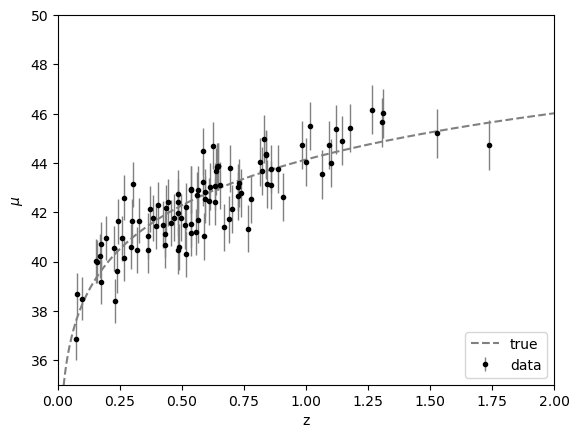

In [3]:
cosmo = LambdaCDM(70, 0.27, 1-0.27)
z = np.linspace(0.01, 2, 1000)
mu_true = cosmo.distmod(z)

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.plot(z, mu_true, '--', c='gray',label='true')
plt.xlabel("z")
plt.ylabel(rf"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

### Polinomial Regression

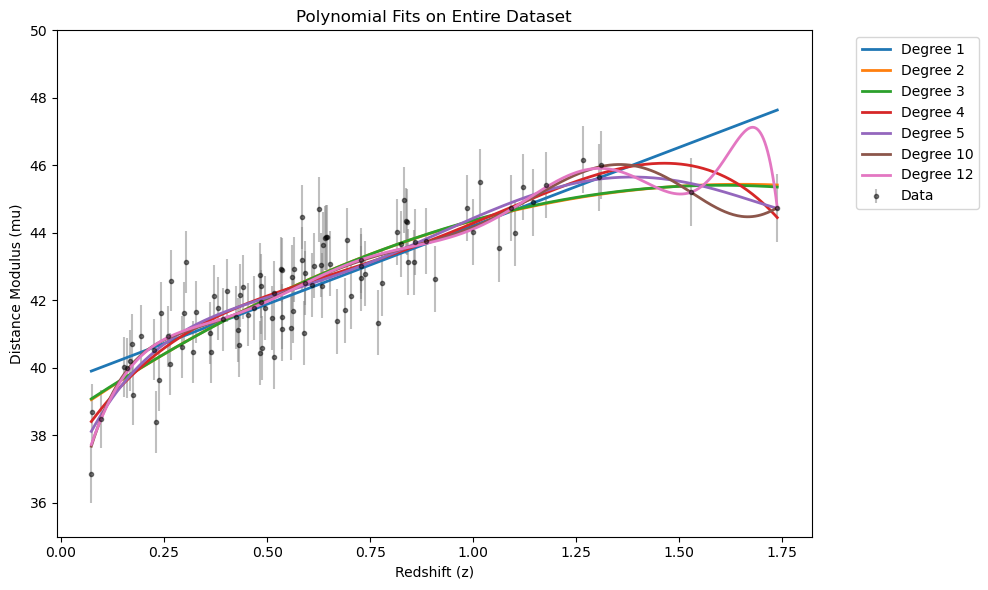

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# prepare data for scikit
# reshape z_sample from shape (100,) to (100, 1)
z = z_sample.reshape(-1, 1)
mu = mu_sample

# dense grid to plot different polinomial functions
z_plot = np.linspace(z.min(), z.max(), 500).reshape(-1, 1)

degrees_to_plot = [1, 2, 3, 4, 5, 10, 12]

plt.figure(figsize=(10, 6))
plt.errorbar(z, mu, yerr=dmu, fmt='.k', ecolor='gray', alpha=0.5, label='Data')

for d in degrees_to_plot:
    # Create a pipeline: generate polynomial features, do linear regression
    # It's an alternative to np.newaxis to extend the dimension of the dataset
    model = make_pipeline(PolynomialFeatures(degree=d), LinearRegression())
    model.fit(z, mu)
    
    # Predict on the dense grid to plot the curve
    mu_pred = model.predict(z_plot)
    plt.plot(z_plot, mu_pred, label=f'Degree {d}', linewidth=2)

plt.title("Polynomial Fits on Entire Dataset")
plt.xlabel("Redshift (z)")
plt.ylabel("Distance Modulus (mu)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(35, 50)
plt.tight_layout()
plt.show()


### Cross Validation

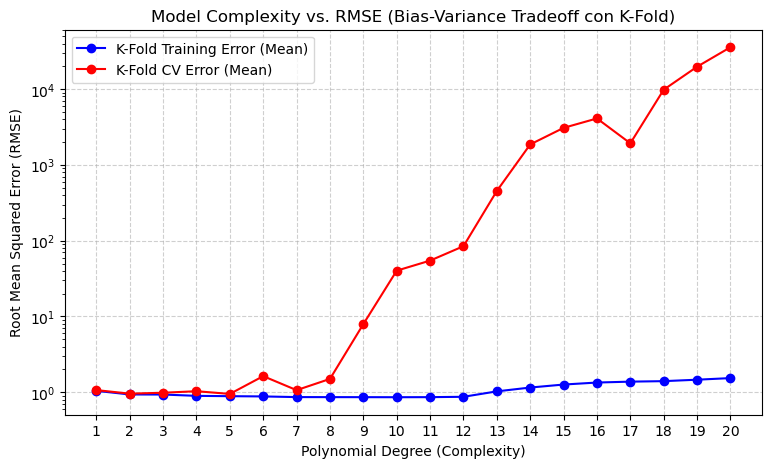

In [5]:
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

z_train, z_val, mu_train, mu_val = train_test_split(z, mu, test_size=0.3, random_state=42)

#to avoid data leakage (scaling including test set) create a pipeline
pipe = make_pipeline(StandardScaler(),PolynomialFeatures(),LinearRegression())
param_grid = {'polynomialfeatures__degree': np.arange(1, 21)}
kf = KFold(n_splits=8, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=kf,
    scoring='neg_root_mean_squared_error', 
    return_train_score=True,              
    n_jobs=-1
)

grid.fit(z_train, mu_train)

# Estrazione dei risultati per la Complexity Curve
# Moltiplichiamo per -1 perché Scikit-Learn restituisce score negativi per la minimizzazione
train_errors = -grid.cv_results_['mean_train_score']
cv_errors = -grid.cv_results_['mean_test_score']
degrees_cv = param_grid['polynomialfeatures__degree']

plt.figure(figsize=(9, 5))
plt.plot(degrees_cv, train_errors, 'o-', color='blue', label='K-Fold Training Error (Mean)')
plt.plot(degrees_cv, cv_errors, 'o-', color='red', label='K-Fold CV Error (Mean)')

plt.title("Model Complexity vs. RMSE (Bias-Variance Tradeoff con K-Fold)")
plt.xlabel("Polynomial Degree (Complexity)")
plt.ylabel("Root Mean Squared Error (RMSE)")
plt.xticks(degrees_cv)
plt.yscale('log')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [6]:
# valutazione finale su dataset indipendetne
best_degree = grid.best_params_['polynomialfeatures__degree']
lowest_cv_error = -grid.best_score_
best_model = grid.best_estimator_ 

# Prediciamo sul 30% escluso all'inizio per il test finale
pred_val = best_model.predict(z_val)
test_rmse = np.sqrt(mean_squared_error(mu_val, pred_val))

print(f"Miglior grado polinomiale (via K-Fold CV): {best_degree}")
print(f"Minimo RMSE di Cross-Validation (medio sui fold): {lowest_cv_error:.4f}")
print(f"Generalization RMSE sul Validation Set indipendente: {test_rmse:.4f}")

Miglior grado polinomiale (via K-Fold CV): 5
Minimo RMSE di Cross-Validation (medio sui fold): 0.9509
Generalization RMSE sul Validation Set indipendente: 0.8124


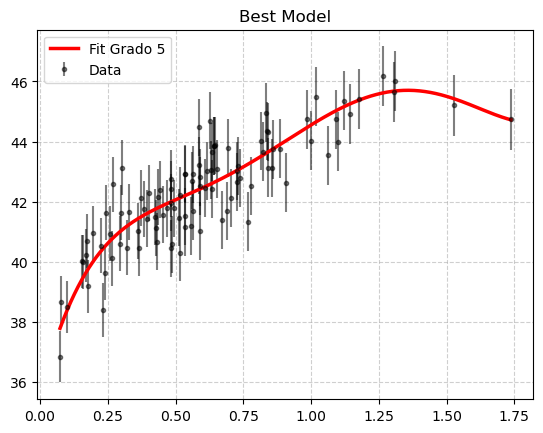

In [7]:
degree=5
best_model = make_pipeline(PolynomialFeatures(degree=degree), LinearRegression()).fit(z_train, mu_train)

plt.figure()
plt.errorbar(z, mu, yerr=dmu, fmt='.k', alpha=0.5, label='Data')
plt.plot(z_plot, best_model.predict(z_plot), 'r-', lw=2.5, label='Fit Grado 5')
plt.grid(True, linestyle='--', alpha=0.6)
plt.title("Best Model")
plt.legend()
plt.show()

[ 5  7  9 11 13 15 17 19 21 23 25 27 29 31 33 35 37 39 41 43 45 47 49 51
 53 55 57 59 61 63 65 67 69]


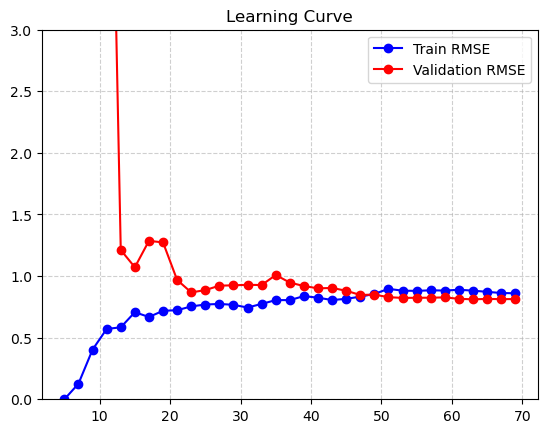

Exception ignored in: <function ResourceTracker.__del__ at 0x108975da0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106f75da0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x103d75da0>
Traceback (most recent call last

In [9]:
# Learning Curve
sz = np.arange(5, len(z_train) + 1, 2)
print(sz)
t_err, v_err = [], []

for m in sz:
    best_model.fit(z_train[:m], mu_train[:m])
    t_err.append(np.sqrt(mean_squared_error(mu_train[:m], best_model.predict(z_train[:m]))))
    v_err.append(np.sqrt(mean_squared_error(mu_val, best_model.predict(z_val))))

plt.figure()
plt.plot(sz, t_err, 'o-b', label='Train RMSE')
plt.plot(sz, v_err, 'o-r', label='Validation RMSE')
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0, 3)
plt.title("Learning Curve")
plt.legend()
plt.show()